# Multi-City Real Estate Price Prediction and Market Analysis

## Project Overview

This project develops a machine learning pipeline for analyzing and predicting residential property prices across multiple Indian cities.

Real-estate datasets from different cities are collected from publicly available datasets and standardized into a common structure. The unified dataset is then cleaned, explored, transformed, and used to develop machine learning models for property price prediction.

The project also analyzes how property characteristics and city/location influence real-estate prices.

## Cities Covered

- Bengaluru
- Mumbai
- Additional cities can be added using the same standardized pipeline.

## Workflow

Data Collection → Data Integration → Data Cleaning → Feature Engineering → EDA → Outlier Treatment → Model Building → Model Comparison → Price Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Load Bengaluru Dataset

The Bengaluru dataset contains residential property information including location, property type, BHK, area, bathrooms, balconies and price.

In [2]:
bengaluru_path = r"...\Real_Estate\Dataset\Bengaluru_House_Data.csv" #use your path

blr_df = pd.read_csv(bengaluru_path)

print("Bengaluru Shape:", blr_df.shape)
display(blr_df.head())

Bengaluru Shape: (13320, 9)


,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


## 2. Load Mumbai Dataset

The Mumbai dataset contains similar real-estate attributes but uses different column naming conventions. These columns will be standardized before combining the datasets.

In [3]:
mumbai_path = r"...\Real_Estate\Dataset\Mumbai_House_Data.xlsx" #use your path

mumbai_df = pd.read_excel(mumbai_path)

print("Mumbai Shape:", mumbai_df.shape)
display(mumbai_df.head())

Mumbai Shape: (11146, 16)


,SR.,AREA_TYPE,LOCATION,SIZE,TOTAL_SQFT,BATH,BALCONY,PRICE IN LAKHS,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,1,Super built-up Area,Dadar,2 BHK,1056,2,1,314,Kurla,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Built-up Area,Andheri,3 BHK,1440,2,3,380,NaN,LOCATION,SIZE,NaN,NaN,NaN,NaN,NaN
2,3,Super built-up Area,Vikhroli,3 BHK,1521,3,1,479,NaN,Kurla,1 BHK,0.026721,NaN,NaN,NaN,NaN
3,4,Super built-up Area,Thane,2 BHK,1200,2,1,319,NaN,Kurla,2 BHK,0.453469,NaN,NaN,NaN,NaN
4,5,Super built-up Area,Dadar,2 BHK,1170,2,1,348,NaN,Kurla,3 BHK,0.428133,NaN,NaN,NaN,NaN


In [4]:
print("BENGALURU COLUMNS")
print(blr_df.columns.tolist())

print("\nMUMBAI COLUMNS")
print(mumbai_df.columns.tolist())

BENGALURU COLUMNS
['area_type', 'availability', 'location', 'size', 'society', 'total_sqft', 'bath', 'balcony', 'price']

MUMBAI COLUMNS
['SR.', 'AREA_TYPE', 'LOCATION', 'SIZE', 'TOTAL_SQFT', 'BATH', 'BALCONY', 'PRICE IN LAKHS', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15']


In [5]:
mumbai_df = mumbai_df.iloc[:, :8].copy()

print("Mumbai Shape after removing unused columns:", mumbai_df.shape)
display(mumbai_df.head())

Mumbai Shape after removing unused columns: (11146, 8)


,SR.,AREA_TYPE,LOCATION,SIZE,TOTAL_SQFT,BATH,BALCONY,PRICE IN LAKHS
0,1,Super built-up Area,Dadar,2 BHK,1056,2,1,314
1,2,Built-up Area,Andheri,3 BHK,1440,2,3,380
2,3,Super built-up Area,Vikhroli,3 BHK,1521,3,1,479
3,4,Super built-up Area,Thane,2 BHK,1200,2,1,319
4,5,Super built-up Area,Dadar,2 BHK,1170,2,1,348


In [6]:
blr_df = blr_df.rename(columns={
    "area_type": "area_type",
    "availability": "availability",
    "location": "location",
    "size": "size",
    "society": "society",
    "total_sqft": "total_sqft",
    "bath": "bath",
    "balcony": "balcony",
    "price": "price"
})

mumbai_df = mumbai_df.rename(columns={
    "AREA_TYPE": "area_type",
    "LOCATION": "location",
    "SIZE": "size",
    "TOTAL_SQFT": "total_sqft",
    "BATH": "bath",
    "BALCONY": "balcony",
    "PRICE IN LAKHS": "price"
})

In [7]:
blr_df["city"] = "Bengaluru"
mumbai_df["city"] = "Mumbai"

In [8]:
common_columns = [
    "city",
    "area_type",
    "location",
    "size",
    "total_sqft",
    "bath",
    "balcony",
    "price"
]

blr_clean = blr_df[common_columns].copy()
mumbai_clean = mumbai_df[common_columns].copy()

print("Bengaluru:", blr_clean.shape)
print("Mumbai:", mumbai_clean.shape)

Bengaluru: (13320, 8)
Mumbai: (11146, 8)


In [9]:
df = pd.concat(
    [blr_clean, mumbai_clean],
    ignore_index=True
)

print("Combined Dataset Shape:", df.shape)

display(df.head())
display(df.tail())

Combined Dataset Shape: (24466, 8)


,city,area_type,location,size,total_sqft,bath,balcony,price
0,Bengaluru,Super built-up Area,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07
1,Bengaluru,Plot Area,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00
2,Bengaluru,Built-up Area,Uttarahalli,3 BHK,1440,2.0,3.0,62.00
3,Bengaluru,Super built-up Area,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00
4,Bengaluru,Super built-up Area,Kothanur,2 BHK,1200,2.0,1.0,51.00


,city,area_type,location,size,total_sqft,bath,balcony,price
24461,Mumbai,Super built-up Area,Dadar,2 BHK,1262,2.0,2.0,385.0
24462,Mumbai,Super built-up Area,Andheri,3 BHK,1345,2.0,1.0,368.0
24463,Mumbai,Super built-up Area,Vashi,3 BHK,1715,3.0,3.0,447.0
24464,Mumbai,Built-up Area,Andheri,2 BHK,1141,2.0,1.0,313.0
24465,Mumbai,Super built-up Area,Andheri,1 BHK,550,1.0,1.0,243.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24466 entries, 0 to 24465
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   city        24466 non-null  object 
 1   area_type   24466 non-null  object 
 2   location    24465 non-null  object 
 3   size        24450 non-null  object 
 4   total_sqft  24466 non-null  object 
 5   bath        24393 non-null  float64
 6   balcony     23857 non-null  float64
 7   price       24466 non-null  float64
dtypes: float64(3), object(5)
memory usage: 1.5+ MB


In [11]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
city,24466,2,Bengaluru,13320,NaN,NaN,NaN,NaN,NaN,NaN,NaN
area_type,24466,4,Super built-up Area,16720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,24465,1315,Andheri,2139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
size,24450,31,2 BHK,10593,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_sqft,24466,3522,1200,843,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bath,24393.0,NaN,NaN,NaN,2.539991,1.107446,1.0,2.0,2.0,3.0,40.0
balcony,23857.0,NaN,NaN,NaN,1.584944,0.799063,0.0,1.0,2.0,2.0,3.0
price,24466.0,NaN,NaN,NaN,228.70102,179.779915,8.0,67.7525,196.0,360.0,3600.0


In [12]:
print("Bengaluru price statistics (₹ lakhs):")
print(blr_clean["price"].describe())

print("\nMumbai price statistics (₹ lakhs):")
print(mumbai_clean["price"].describe())

Bengaluru price statistics (₹ lakhs):
count    13320.000000
mean       112.565627
std        148.971674
min          8.000000
25%         50.000000
50%         72.000000
75%        120.000000
max       3600.000000
Name: price, dtype: float64

Mumbai price statistics (₹ lakhs):
count    11146.000000
mean       367.488337
std         95.102218
min        150.000000
25%        317.000000
50%        360.000000
75%        411.000000
max        700.000000
Name: price, dtype: float64


## Missing Value Handling Strategy

Missing values are handled based on their percentage and the importance of each feature.

- Columns with very high missing percentages would be considered for removal.
- Numerical features with low missing percentages are retained and imputed.
- Critical categorical features such as location are handled by removing records with missing values when the number of affected records is negligible.
- The `size` feature is required for deriving BHK, so records with missing size are removed.
- Balcony and bathroom values are imputed using group-level statistics where possible.

In [13]:
for city in df["city"].unique():
    print(f"\n--- {city} ---")
    display(
        df[df["city"] == city]
        .isnull()
        .sum()
        .to_frame("Missing")
    )


--- Bengaluru ---


,Missing
city,0
area_type,0
location,1
size,16
total_sqft,0
bath,73
balcony,609
price,0



--- Mumbai ---


,Missing
city,0
area_type,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0


In [14]:
missing_percent = df.isnull().mean() * 100

high_missing_columns = missing_percent[
    missing_percent > 40
].index.tolist()

print("Columns with >40% missing values:")
print(high_missing_columns)

Columns with >40% missing values:
[]


In [15]:
print("Missing size before:", df["size"].isnull().sum())

df = df.dropna(subset=["size"]).copy()

print("Missing size after:", df["size"].isnull().sum())
print("New shape:", df.shape)

Missing size before: 16
Missing size after: 0
New shape: (24450, 8)


In [16]:
print("Missing location before:", df["location"].isnull().sum())

Missing location before: 1


In [17]:
df = df.dropna(subset=["location"]).copy()

print("Missing location after:", df["location"].isnull().sum())

Missing location after: 0


In [18]:
df["bhk"] = (
    df["size"]
    .str.extract(r"(\d+)")[0]
)

df["bhk"] = pd.to_numeric(
    df["bhk"],
    errors="coerce"
)

In [19]:
print("Missing BHK:", df["bhk"].isnull().sum())

Missing BHK: 0


In [20]:
display(
    df[df["bhk"].isnull()][["city", "size"]]
)

,city,size


In [21]:
print("Missing balcony before:",
      df["balcony"].isnull().sum())

Missing balcony before: 593


In [22]:
group_median = (
    df.groupby(["city", "bhk", "area_type"])["balcony"]
      .transform("median")
)

df["balcony"] = df["balcony"].fillna(group_median)

city_median = (
    df.groupby("city")["balcony"]
      .transform("median")
)

df["balcony"] = df["balcony"].fillna(city_median)

print("Missing balcony after:",
      df["balcony"].isnull().sum())

Missing balcony after: 0


In [23]:
print("Missing bath before:",
      df["bath"].isnull().sum())

Missing bath before: 57


In [24]:
group_median = (
    df.groupby(["city", "bhk"])["bath"]
      .transform("median")
)

df["bath"] = df["bath"].fillna(group_median)

city_median = (
    df.groupby("city")["bath"]
      .transform("median")
)

df["bath"] = df["bath"].fillna(city_median)

print("Missing bath after:",
      df["bath"].isnull().sum())

Missing bath after: 0


In [25]:
missing_final = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing Percentage": df.isnull().mean() * 100
})

display(
    missing_final.sort_values(
        "Missing Percentage",
        ascending=False
    )
)

,Missing Values,Missing Percentage
city,0,0.0
area_type,0,0.0
location,0,0.0
size,0,0.0
total_sqft,0,0.0
bath,0,0.0
balcony,0,0.0
price,0,0.0
bhk,0,0.0


In [26]:
def convert_sqft_to_num(value):
    try:
        value = str(value).strip()

        if "-" in value:
            low, high = value.split("-")
            return (float(low) + float(high)) / 2

        return float(value)

    except:
        return np.nan

In [27]:
df["total_sqft"] = df["total_sqft"].apply(
    convert_sqft_to_num
)

df["total_sqft"] = pd.to_numeric(
    df["total_sqft"],
    errors="coerce"
)

In [28]:
print("Missing total_sqft:",
      df["total_sqft"].isnull().sum())

display(df["total_sqft"].describe())

Missing total_sqft: 46


count    24403.000000
mean      1462.329436
std        963.506933
min          1.000000
25%       1100.000000
50%       1255.000000
75%       1606.500000
max      52272.000000
Name: total_sqft, dtype: float64

In [29]:
df = df[
    (df["total_sqft"] > 0) &
    (df["price"] > 0) &
    (df["bhk"] > 0)
].copy()

print("Shape:", df.shape)

Shape: (24403, 9)


### price = ₹ lakhs

₹1 lakh = ₹100,000

Therefore:

price_per_sqft =
(price × 100000) / total_sqft

In [30]:
df["price_per_sqft"] = (
    df["price"] * 100000
) / df["total_sqft"]

In [31]:
display(
    df[
        [
            "city",
            "location",
            "size",
            "bhk",
            "total_sqft",
            "bath",
            "balcony",
            "price",
            "price_per_sqft"
        ]
    ].head(20)
)

,city,location,size,bhk,total_sqft,bath,balcony,price,price_per_sqft
0,Bengaluru,Electronic City Phase II,2 BHK,2,1056.0,2.0,1.0,39.07,3699.810606
1,Bengaluru,Chikka Tirupathi,4 Bedroom,4,2600.0,5.0,3.0,120.00,4615.384615
2,Bengaluru,Uttarahalli,3 BHK,3,1440.0,2.0,3.0,62.00,4305.555556
3,Bengaluru,Lingadheeranahalli,3 BHK,3,1521.0,3.0,1.0,95.00,6245.890861
4,Bengaluru,Kothanur,2 BHK,2,1200.0,2.0,1.0,51.00,4250.000000
5,Bengaluru,Whitefield,2 BHK,2,1170.0,2.0,1.0,38.00,3247.863248
6,Bengaluru,Old Airport Road,4 BHK,4,2732.0,4.0,2.0,204.00,7467.057101
7,Bengaluru,Rajaji Nagar,4 BHK,4,3300.0,4.0,2.0,600.00,18181.818182
8,Bengaluru,Marathahalli,3 BHK,3,1310.0,3.0,1.0,63.25,4828.244275
9,Bengaluru,Gandhi Bazar,6 Bedroom,6,1020.0,6.0,2.0,370.00,36274.509804


In [32]:
display(
    df.groupby("city")[
        ["total_sqft", "bhk", "bath", "price", "price_per_sqft"]
    ].describe().T
)

city                     Bengaluru        Mumbai
total_sqft     count  1.325700e+04  11146.000000
               mean   1.558809e+03   1347.576889
               std    1.238479e+03    428.971592
               min    1.000000e+00    502.000000
               25%    1.100000e+03   1095.000000
               50%    1.275000e+03   1246.000000
               75%    1.680000e+03   1550.000000
               max    5.227200e+04   3000.000000
bhk            count  1.325700e+04  11146.000000
               mean   2.802670e+00      2.511394
               std    1.292117e+00      0.718596
               min    1.000000e+00      1.000000
               25%    2.000000e+00      2.000000
               50%    3.000000e+00      2.000000
               75%    3.000000e+00      3.000000
               max    4.300000e+01      5.000000
bath           count  1.325700e+04  11146.000000
               mean   2.693445e+00      2.358604
               std    1.338188e+00      0.696312
               min    1.000000e+00      1.000000
               25%    2.000000e+00      2.000000
               50%    2.000000e+00      2.000000
               75%    3.000000e+00      3.000000
               max    4.000000e+01      4.000000
price          count  1.325700e+04  11146.000000
               mean   1.124720e+02    367.488337
               std    1.490927e+02     95.102218
               min    8.000000e+00    150.000000
               25%    5.000000e+01    317.000000
               50%    7.200000e+01    360.000000
               75%    1.200000e+02    411.000000
               max    3.600000e+03    700.000000
price_per_sqft count  1.325700e+04  11146.000000
               mean   7.912825e+03  27995.135730
               std    1.064976e+05   4725.170252
               min    2.678298e+02  15100.000000
               25%    4.271186e+03  24836.060321
               50%    5.438596e+03  27500.000000
               75%    7.313318e+03  30615.384615
               max    1.200000e+07  57115.384615

In [33]:
# Ensure balcony contains whole-number values
df["balcony"] = np.rint(df["balcony"]).astype(int)

print("Balcony values:")
print(sorted(df["balcony"].unique()))

print("\nMissing balcony:", df["balcony"].isnull().sum())

Balcony values:
[0, 1, 2, 3]

Missing balcony: 0


## 6. Outlier Analysis

Outlier analysis is performed before model development because extreme property measurements can disproportionately influence regression models.

The distributions of property area and price per square foot are visualized first. Statistical outliers are then identified using the Interquartile Range (IQR) method separately for each city.

In [34]:
print("Largest properties:")
display(
    df[
        ["city", "location", "size", "bhk", "total_sqft", "price"]
    ]
    .sort_values("total_sqft", ascending=False)
    .head(20)
)

Largest properties:


,city,location,size,bhk,total_sqft,price
1894,Bengaluru,Nelamangala,3 Bedroom,3,52272.0,140.0
5393,Bengaluru,Doddabommasandra,9 BHK,9,42000.0,175.0
5469,Bengaluru,Ulsoor,4 BHK,4,36000.0,450.0
674,Bengaluru,Yelahanka,3 BHK,3,35000.0,130.0
12987,Bengaluru,Dodsworth Layout,6 Bedroom,6,30400.0,1824.0
2623,Bengaluru,Dodsworth Layout,4 Bedroom,4,30000.0,2100.0
7242,Bengaluru,Yelahanka,1 Bedroom,1,26136.0,150.0
7947,Bengaluru,JP Nagar,3 BHK,3,20000.0,175.0
12470,Bengaluru,Nagashetty Halli,4 BHK,4,16335.0,149.0
1234,Bengaluru,Siddapura,4 Bedroom,4,14000.0,800.0


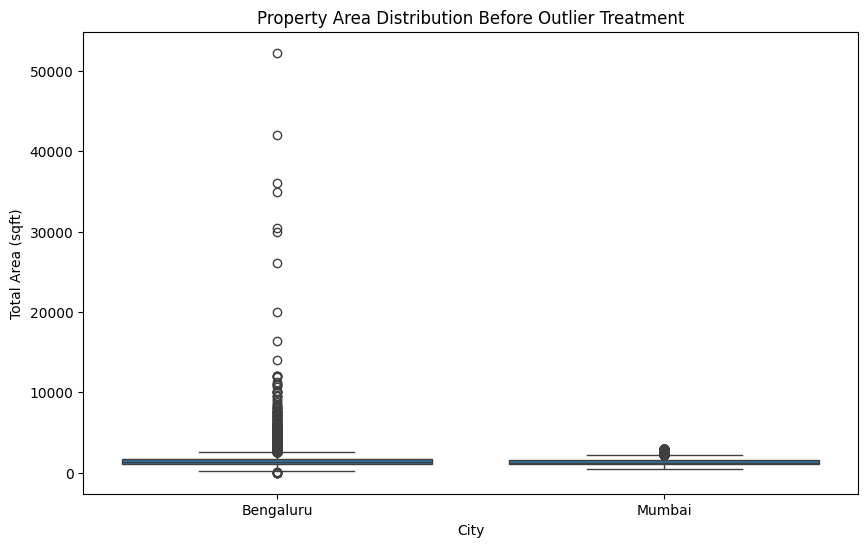

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="city",
    y="total_sqft"
)

plt.title("Property Area Distribution Before Outlier Treatment")
plt.xlabel("City")
plt.ylabel("Total Area (sqft)")
plt.show()

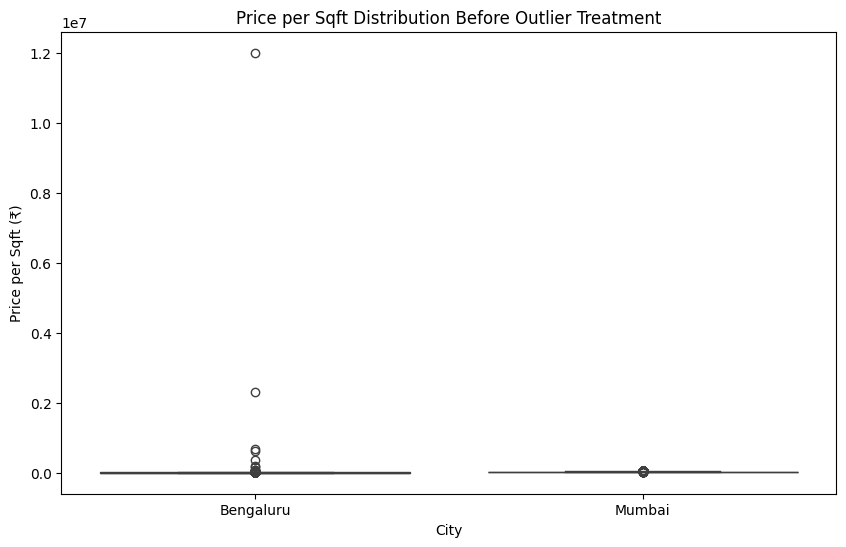

In [36]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="city",
    y="price_per_sqft"
)

plt.title("Price per Sqft Distribution Before Outlier Treatment")
plt.xlabel("City")
plt.ylabel("Price per Sqft (₹)")
plt.show()

### Statistical Outlier Detection

The Interquartile Range (IQR) method is used to identify observations outside the typical distribution.

For each city:

- Q1 represents the 25th percentile.
- Q3 represents the 75th percentile.
- IQR = Q3 − Q1.
- Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are considered statistical outliers.

In [37]:
def get_iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    return q1, q3, lower, upper

In [38]:
outlier_summary = []

for city in df["city"].unique():

    city_data = df[df["city"] == city]

    # Total sqft
    sqft_q1, sqft_q3, sqft_lower, sqft_upper = get_iqr_bounds(
        city_data["total_sqft"]
    )

    # Price per sqft
    pps_q1, pps_q3, pps_lower, pps_upper = get_iqr_bounds(
        city_data["price_per_sqft"]
    )

    outlier_summary.append({
        "City": city,
        "Sqft Q1": sqft_q1,
        "Sqft Q3": sqft_q3,
        "Sqft Lower Bound": sqft_lower,
        "Sqft Upper Bound": sqft_upper,
        "PPS Q1": pps_q1,
        "PPS Q3": pps_q3,
        "PPS Lower Bound": pps_lower,
        "PPS Upper Bound": pps_upper
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

,City,Sqft Q1,Sqft Q3,Sqft Lower Bound,Sqft Upper Bound,PPS Q1,PPS Q3,PPS Lower Bound,PPS Upper Bound
0,Bengaluru,1100.0,1680.0,230.0,2550.0,4271.186441,7313.317937,-292.010804,11876.515181
1,Mumbai,1095.0,1550.0,412.5,2232.5,24836.060321,30615.384615,16167.073880,39284.371057


In [39]:
for city in df["city"].unique():

    city_data = df[df["city"] == city]

    _, _, sqft_lower, sqft_upper = get_iqr_bounds(
        city_data["total_sqft"]
    )

    _, _, pps_lower, pps_upper = get_iqr_bounds(
        city_data["price_per_sqft"]
    )

    sqft_outliers = (
        (city_data["total_sqft"] < sqft_lower) |
        (city_data["total_sqft"] > sqft_upper)
    ).sum()

    pps_outliers = (
        (city_data["price_per_sqft"] < pps_lower) |
        (city_data["price_per_sqft"] > pps_upper)
    ).sum()

    print(f"\n{city}")
    print("Total sqft outliers:", sqft_outliers)
    print("Price/sqft outliers:", pps_outliers)


Bengaluru
Total sqft outliers: 1165
Price/sqft outliers: 1267

Mumbai
Total sqft outliers: 559
Price/sqft outliers: 227


In [40]:
# Create area per BHK feature
df["sqft_per_bhk"] = df["total_sqft"] / df["bhk"]

display(
    df[
        ["city", "location", "size", "bhk",
         "total_sqft", "sqft_per_bhk",
         "price", "price_per_sqft"]
    ]
    .sort_values("sqft_per_bhk", ascending=False)
    .head(20)
)

,city,location,size,bhk,total_sqft,sqft_per_bhk,price,price_per_sqft
7242,Bengaluru,Yelahanka,1 Bedroom,1,26136.0,26136.000000,150.0,573.921028
1894,Bengaluru,Nelamangala,3 Bedroom,3,52272.0,17424.000000,140.0,267.829813
674,Bengaluru,Yelahanka,3 BHK,3,35000.0,11666.666667,130.0,371.428571
10075,Bengaluru,"Yelahanka,MVIT college",1 Bedroom,1,10030.0,10030.000000,150.0,1495.513460
5469,Bengaluru,Ulsoor,4 BHK,4,36000.0,9000.000000,450.0,1250.000000
2623,Bengaluru,Dodsworth Layout,4 Bedroom,4,30000.0,7500.000000,2100.0,7000.000000
7947,Bengaluru,JP Nagar,3 BHK,3,20000.0,6666.666667,175.0,875.000000
7824,Bengaluru,Sector 1 HSR Layout,1 BHK,1,6000.0,6000.000000,276.0,4600.000000
12987,Bengaluru,Dodsworth Layout,6 Bedroom,6,30400.0,5066.666667,1824.0,6000.000000
5393,Bengaluru,Doddabommasandra,9 BHK,9,42000.0,4666.666667,175.0,416.666667


In [41]:
display(
    df[
        ["city", "location", "size", "bhk",
         "total_sqft", "sqft_per_bhk",
         "price", "price_per_sqft"]
    ]
    .sort_values("price_per_sqft", ascending=False)
    .head(20)
)

,city,location,size,bhk,total_sqft,sqft_per_bhk,price,price_per_sqft
4086,Bengaluru,Sarjapur Road,4 Bedroom,4,1.0,0.250000,120.0,1.200000e+07
4972,Bengaluru,Srirampuram,7 BHK,7,5.0,0.714286,115.0,2.300000e+06
349,Bengaluru,Suragajakkanahalli,3 Bedroom,3,11.0,3.666667,74.0,6.727273e+05
1122,Bengaluru,Grihalakshmi Layout,5 Bedroom,5,24.0,4.800000,150.0,6.250000e+05
11558,Bengaluru,Whitefield,4 Bedroom,4,60.0,15.000000,218.0,3.633333e+05
1020,Bengaluru,Weavers Colony,1 BHK,1,15.0,15.000000,30.0,2.000000e+05
7657,Bengaluru,Raghuvanahalli,1 BHK,1,425.0,425.000000,750.0,1.764706e+05
7088,Bengaluru,Srirampuram,1 BHK,1,650.0,650.000000,500.0,7.692308e+04
6421,Bengaluru,Bommenahalli,4 Bedroom,4,2940.0,735.000000,2250.0,7.653061e+04
12443,Bengaluru,Dollars Colony,4 Bedroom,4,4350.0,1087.500000,2600.0,5.977011e+04


## Outlier Treatment

Because Bengaluru and Mumbai have different real-estate price distributions, a single global threshold would not be appropriate.

City-specific IQR boundaries are therefore applied to:
1. Total property area
2. Price per square foot

Observations outside the city-specific bounds are removed before further exploratory analysis and machine learning.

In [42]:
# Flag statistical outliers without deleting them

df["sqft_outlier"] = False
df["pps_outlier"] = False

for city in df["city"].unique():

    city_mask = df["city"] == city
    city_data = df.loc[city_mask]

    _, _, sqft_lower, sqft_upper = get_iqr_bounds(
        city_data["total_sqft"]
    )

    _, _, pps_lower, pps_upper = get_iqr_bounds(
        city_data["price_per_sqft"]
    )

    df.loc[city_mask, "sqft_outlier"] = (
        (df.loc[city_mask, "total_sqft"] < sqft_lower) |
        (df.loc[city_mask, "total_sqft"] > sqft_upper)
    )

    df.loc[city_mask, "pps_outlier"] = (
        (df.loc[city_mask, "price_per_sqft"] < pps_lower) |
        (df.loc[city_mask, "price_per_sqft"] > pps_upper)
    )

print("Area outliers:", df["sqft_outlier"].sum())
print("Price/sqft outliers:", df["pps_outlier"].sum())

Area outliers: 1724
Price/sqft outliers: 1494


In [43]:
display(
    df[df["sqft_outlier"] | df["pps_outlier"]][
        ["city", "location", "bhk", "total_sqft",
         "sqft_per_bhk", "price", "price_per_sqft"]
    ].head(30)
)

,city,location,bhk,total_sqft,sqft_per_bhk,price,price_per_sqft
1,Bengaluru,Chikka Tirupathi,4,2600.0,650.000000,120.0,4615.384615
6,Bengaluru,Old Airport Road,4,2732.0,683.000000,204.0,7467.057101
7,Bengaluru,Rajaji Nagar,4,3300.0,825.000000,600.0,18181.818182
9,Bengaluru,Gandhi Bazar,6,1020.0,170.000000,370.0,36274.509804
11,Bengaluru,Whitefield,4,2785.0,696.250000,295.0,10592.459605
18,Bengaluru,Ramakrishnappa Layout,3,2770.0,923.333333,290.0,10469.314079
22,Bengaluru,Thanisandra,4,2800.0,700.000000,380.0,13571.428571
45,Bengaluru,HSR Layout,8,600.0,75.000000,200.0,33333.333333
48,Bengaluru,KR Puram,2,800.0,400.000000,130.0,16250.000000
56,Bengaluru,Devanahalli,4,3210.0,802.500000,192.0,5981.308411


In [44]:
# Keep all observations; only flag potential outliers

print("Total records:", len(df))
print("Area outliers flagged:", df["sqft_outlier"].sum())
print("Price/sqft outliers flagged:", df["pps_outlier"].sum())

Total records: 24403
Area outliers flagged: 1724
Price/sqft outliers flagged: 1494


IQR was used to identify statistical outliers, but the flagged observations were retained because an outlier is not necessarily an erroneous observation in real-estate data. Large properties and high-value properties can be legitimate. Only records confirmed as implausible through domain-level inspection should be removed

## 7. Correlation Analysis

Correlation analysis is used to examine the linear relationship between numerical property attributes and price.

The correlation matrix helps identify variables that may have stronger relationships with property price before machine learning.

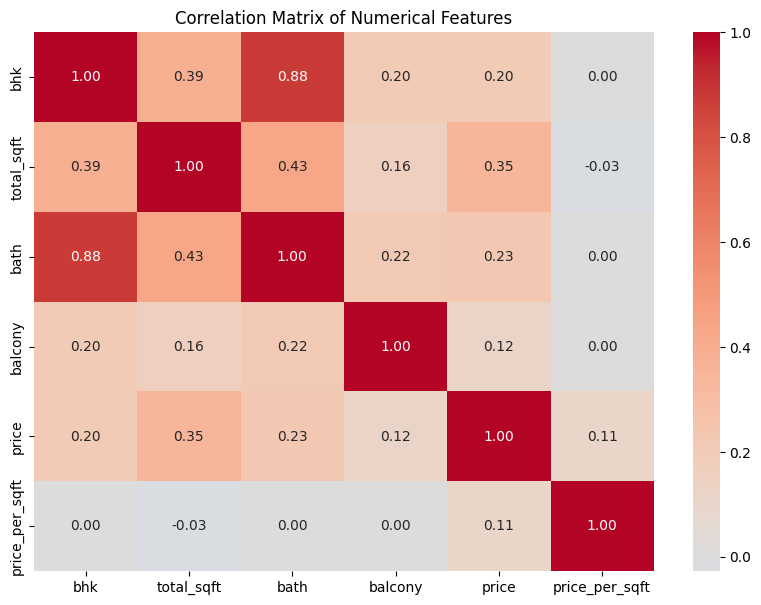

In [45]:
numeric_columns = [
    "bhk",
    "total_sqft",
    "bath",
    "balcony",
    "price",
    "price_per_sqft"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

## 8. Univariate Analysis

Univariate analysis examines individual variables independently to understand their distributions, frequency and central tendency.

The analysis focuses on:

- Property price
- Total area
- BHK
- Bathrooms
- Balconies
- Property type
- City

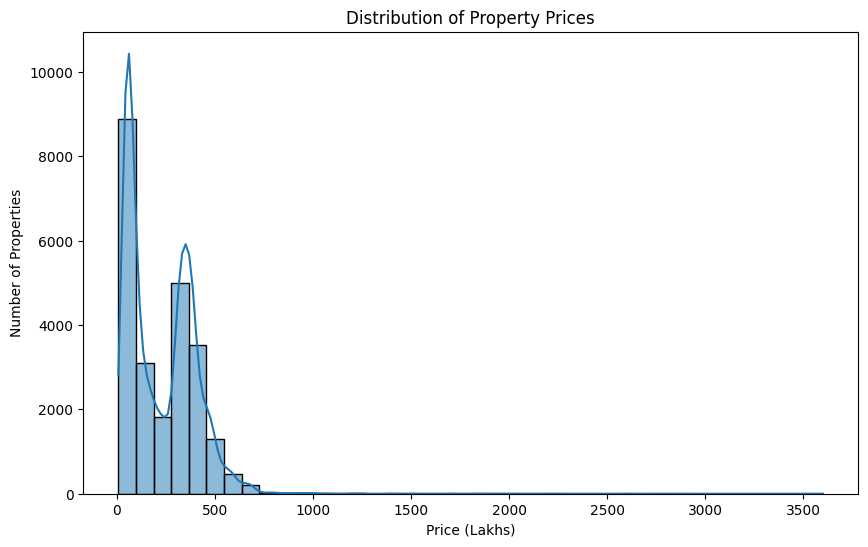

In [46]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="price",
    bins=40,
    kde=True
)

plt.title("Distribution of Property Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Properties")
plt.show()

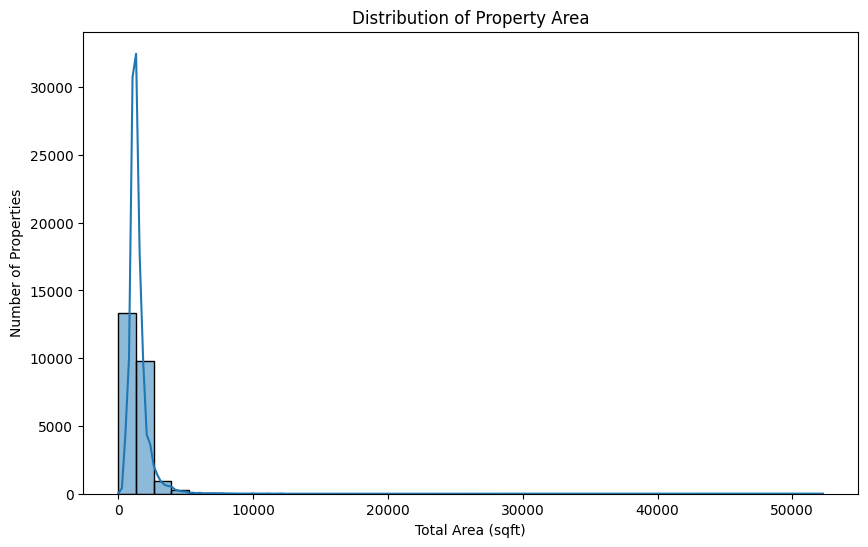

In [47]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="total_sqft",
    bins=40,
    kde=True
)

plt.title("Distribution of Property Area")
plt.xlabel("Total Area (sqft)")
plt.ylabel("Number of Properties")
plt.show()

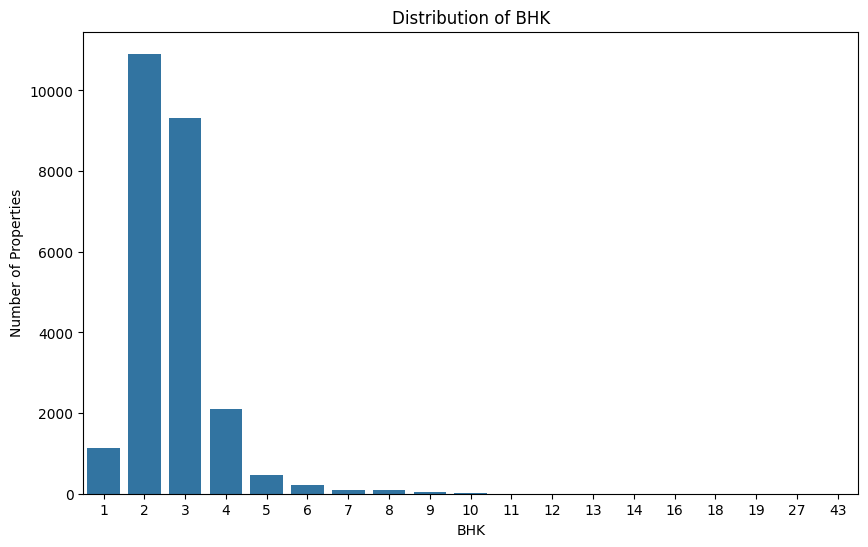

In [48]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="bhk"
)

plt.title("Distribution of BHK")
plt.xlabel("BHK")
plt.ylabel("Number of Properties")
plt.show()

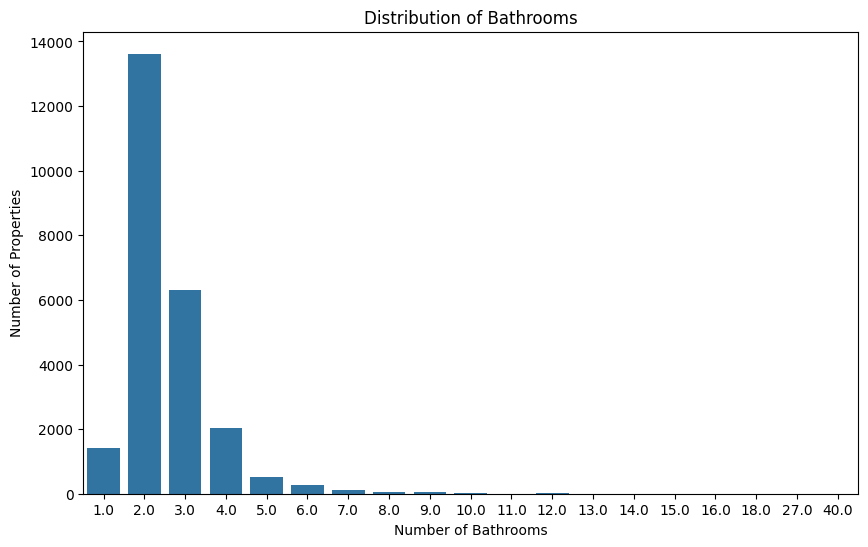

In [49]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="bath"
)

plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Number of Properties")
plt.show()

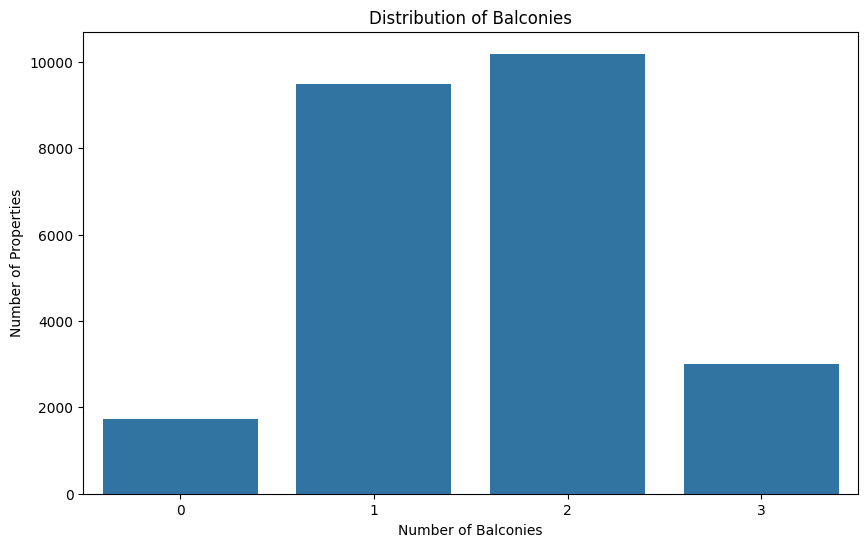

In [50]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="balcony"
)

plt.title("Distribution of Balconies")
plt.xlabel("Number of Balconies")
plt.ylabel("Number of Properties")
plt.show()

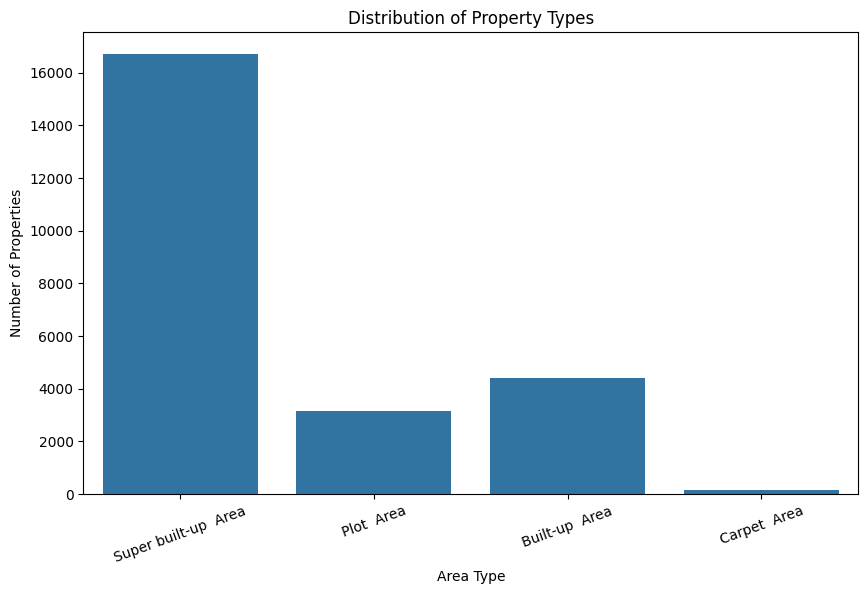

In [51]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="area_type"
)

plt.title("Distribution of Property Types")
plt.xlabel("Area Type")
plt.ylabel("Number of Properties")
plt.xticks(rotation=20)
plt.show()

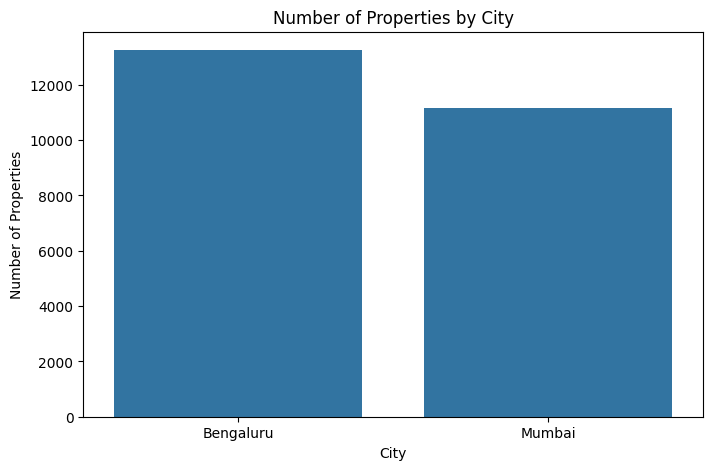

In [52]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="city"
)

plt.title("Number of Properties by City")
plt.xlabel("City")
plt.ylabel("Number of Properties")
plt.show()

## 9. Bivariate Analysis

Bivariate analysis examines the relationship between two variables.

The following relationships are investigated:

- Property area vs price
- BHK vs price
- Bathrooms vs price
- City vs price
- Property type vs price

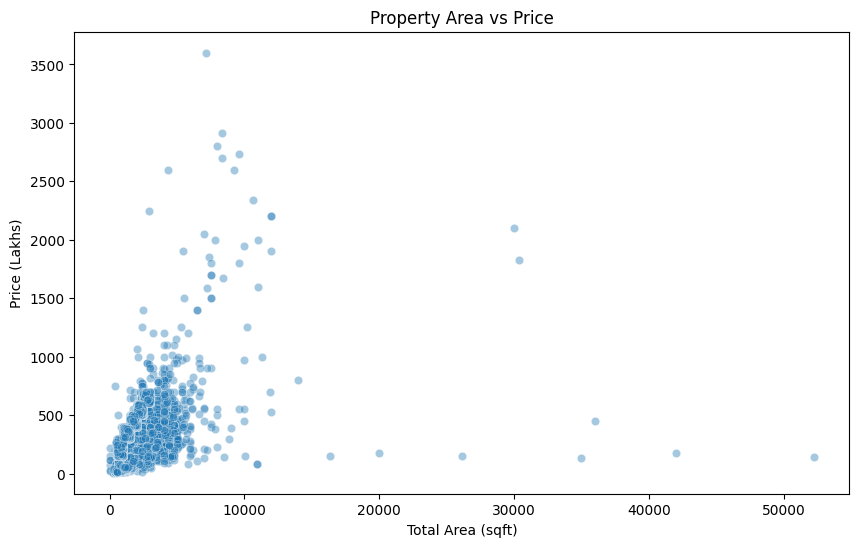

In [53]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="total_sqft",
    y="price",
    alpha=0.4
)

plt.title("Property Area vs Price")
plt.xlabel("Total Area (sqft)")
plt.ylabel("Price (Lakhs)")
plt.show()

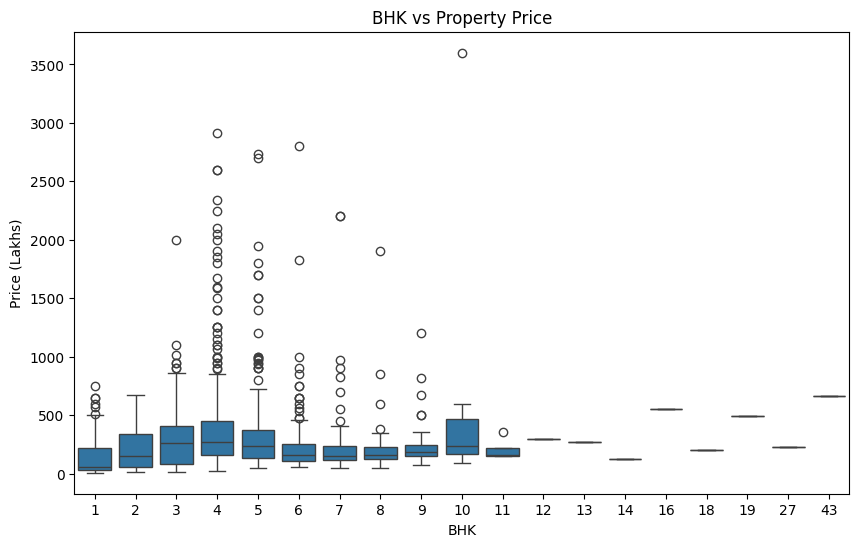

In [54]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="bhk",
    y="price"
)

plt.title("BHK vs Property Price")
plt.xlabel("BHK")
plt.ylabel("Price (Lakhs)")
plt.show()

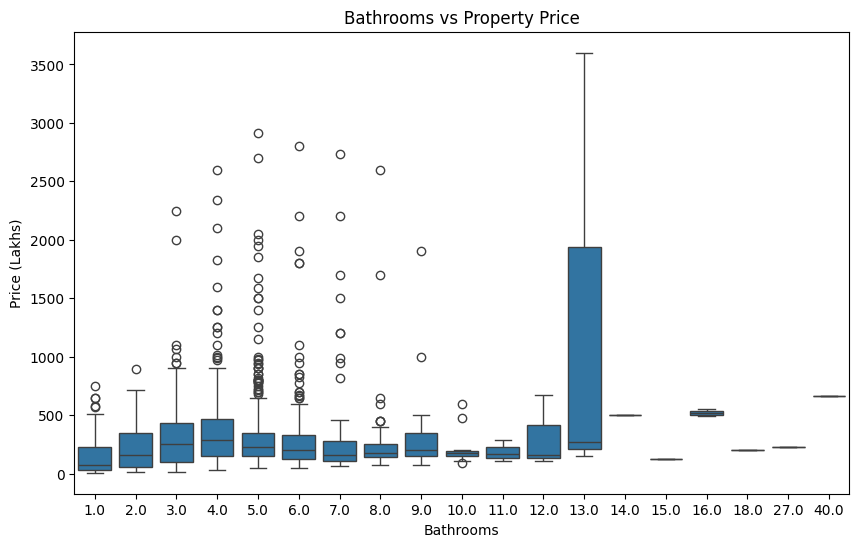

In [55]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="bath",
    y="price"
)

plt.title("Bathrooms vs Property Price")
plt.xlabel("Bathrooms")
plt.ylabel("Price (Lakhs)")
plt.show()

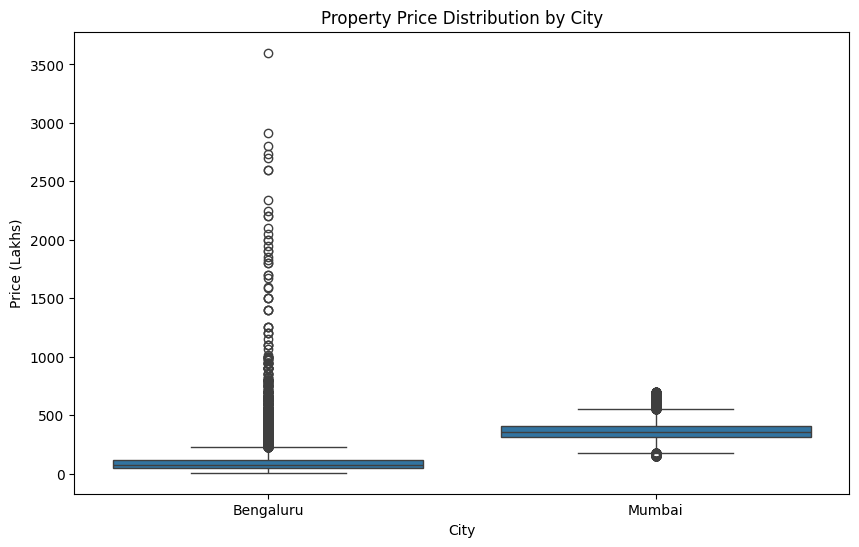

In [56]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="city",
    y="price"
)

plt.title("Property Price Distribution by City")
plt.xlabel("City")
plt.ylabel("Price (Lakhs)")
plt.show()

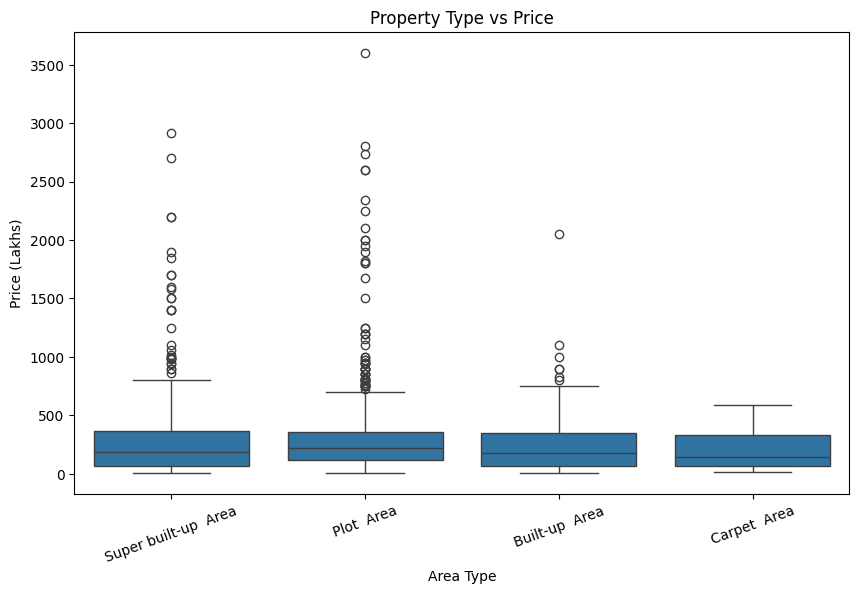

In [57]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="area_type",
    y="price"
)

plt.title("Property Type vs Price")
plt.xlabel("Area Type")
plt.ylabel("Price (Lakhs)")
plt.xticks(rotation=20)
plt.show()

## 10. Trivariate Analysis

Trivariate analysis examines the interaction between three variables simultaneously.

The relationship between property area and price is analyzed while using city as a third variable to identify differences between city-level markets.

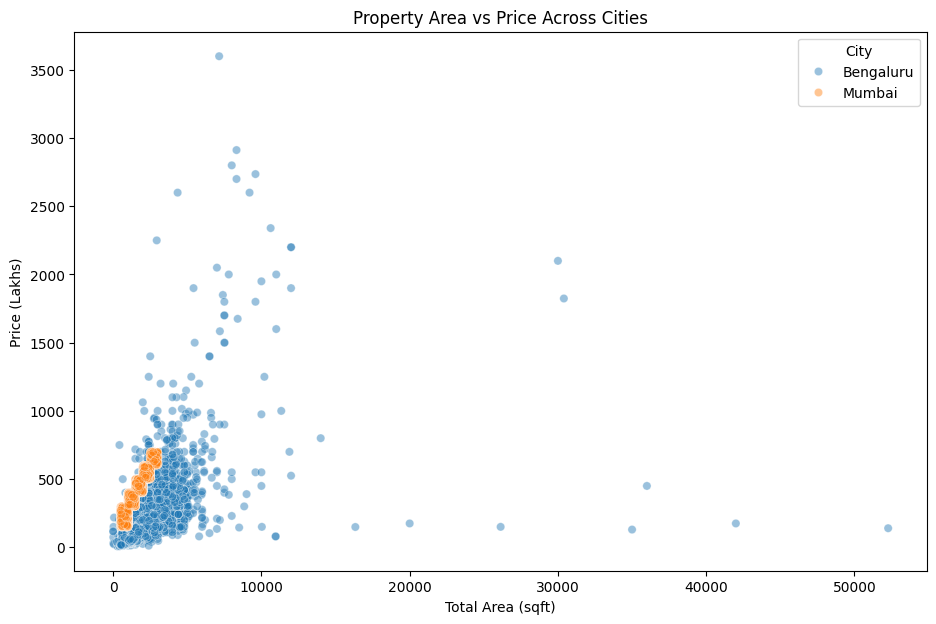

In [58]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="total_sqft",
    y="price",
    hue="city",
    alpha=0.45
)

plt.title("Property Area vs Price Across Cities")
plt.xlabel("Total Area (sqft)")
plt.ylabel("Price (Lakhs)")
plt.legend(title="City")
plt.show()

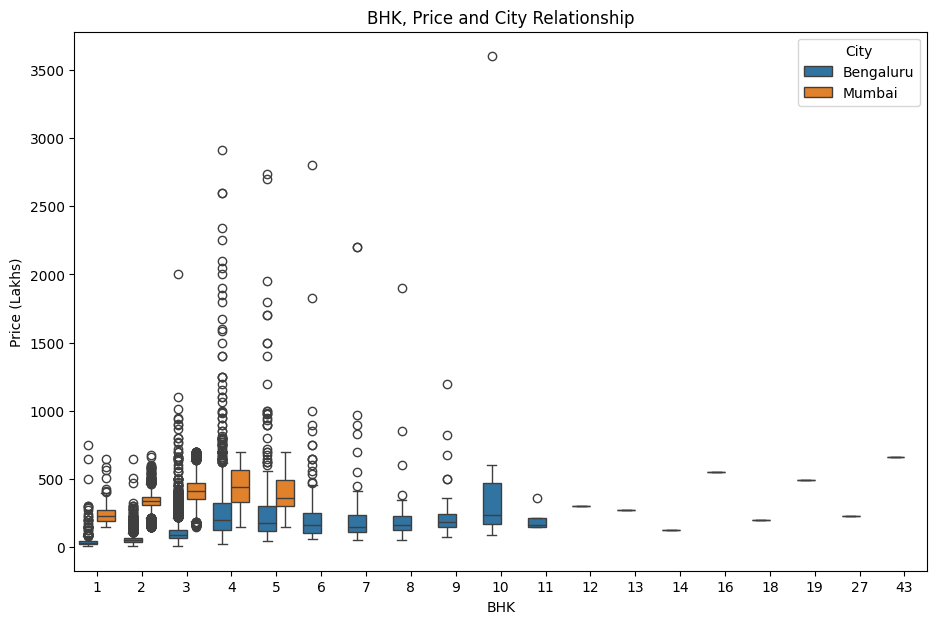

In [59]:
plt.figure(figsize=(11, 7))

sns.boxplot(
    data=df,
    x="bhk",
    y="price",
    hue="city"
)

plt.title("BHK, Price and City Relationship")
plt.xlabel("BHK")
plt.ylabel("Price (Lakhs)")
plt.legend(title="City")
plt.show()

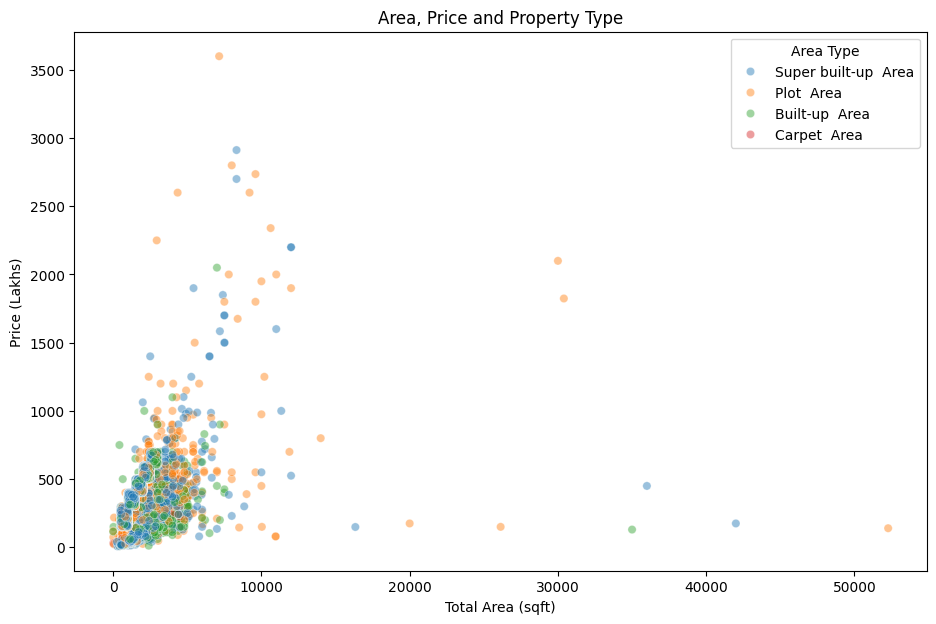

In [60]:
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=df,
    x="total_sqft",
    y="price",
    hue="area_type",
    alpha=0.45
)

plt.title("Area, Price and Property Type")
plt.xlabel("Total Area (sqft)")
plt.ylabel("Price (Lakhs)")
plt.legend(title="Area Type")
plt.show()

In [61]:
city_summary = (
    df.groupby("city")
      .agg(
          Properties=("price", "count"),
          Average_Price=("price", "mean"),
          Median_Price=("price", "median"),
          Average_Area=("total_sqft", "mean"),
          Median_Area=("total_sqft", "median"),
          Average_Price_per_Sqft=("price_per_sqft", "mean"),
          Median_Price_per_Sqft=("price_per_sqft", "median")
      )
      .round(2)
)

display(city_summary)

,Properties,Average_Price,Median_Price,Average_Area,Median_Area,Average_Price_per_Sqft,Median_Price_per_Sqft
city,,,,,,,
Bengaluru,13257,112.47,72.0,1558.81,1275.0,7912.83,5438.6
Mumbai,11146,367.49,360.0,1347.58,1246.0,27995.14,27500.0


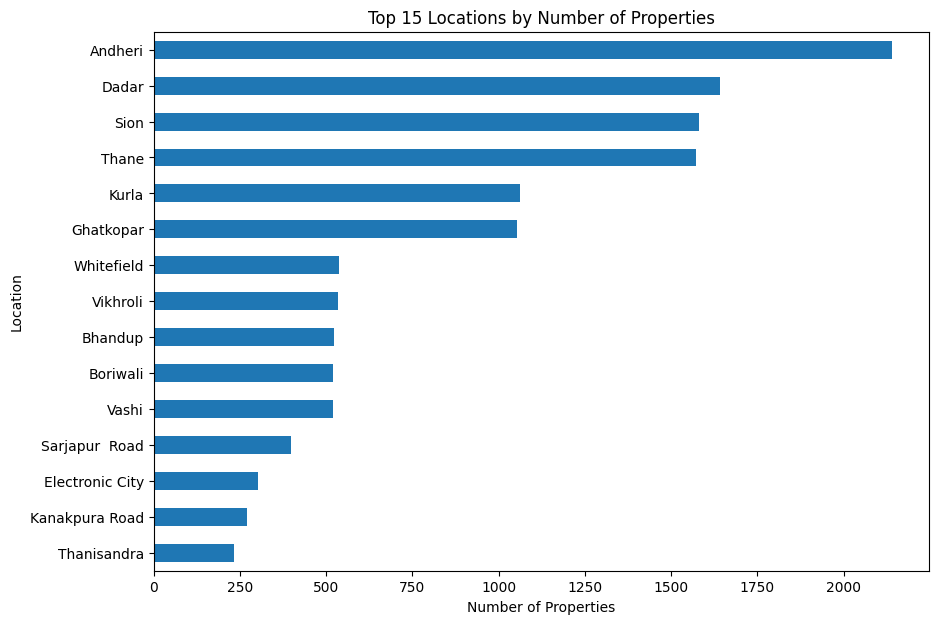

In [62]:
top_locations = (
    df["location"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10, 7))

top_locations.sort_values().plot(
    kind="barh"
)

plt.title("Top 15 Locations by Number of Properties")
plt.xlabel("Number of Properties")
plt.ylabel("Location")
plt.show()

In [63]:
os.makedirs("data/processed", exist_ok=True)

df.to_csv(
    "data/processed/multicity_real_estate_eda_cleaned.csv",
    index=False
)

print("EDA-ready dataset saved successfully.")
print("Shape:", df.shape)

EDA-ready dataset saved successfully.
Shape: (24403, 13)


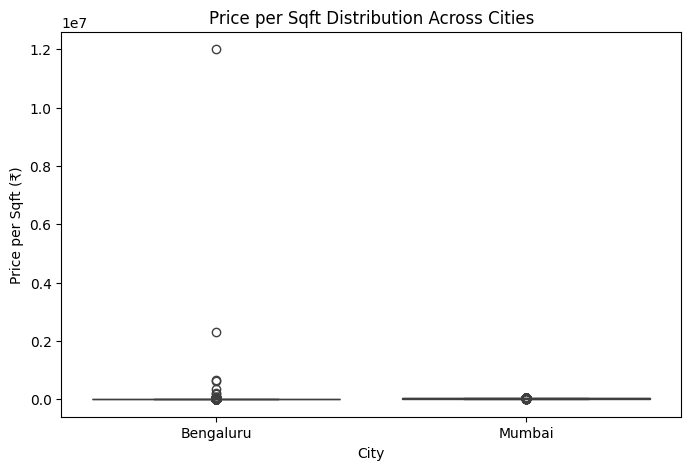

In [64]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="city", y="price_per_sqft")
plt.title("Price per Sqft Distribution Across Cities")
plt.xlabel("City")
plt.ylabel("Price per Sqft (₹)")
plt.show()

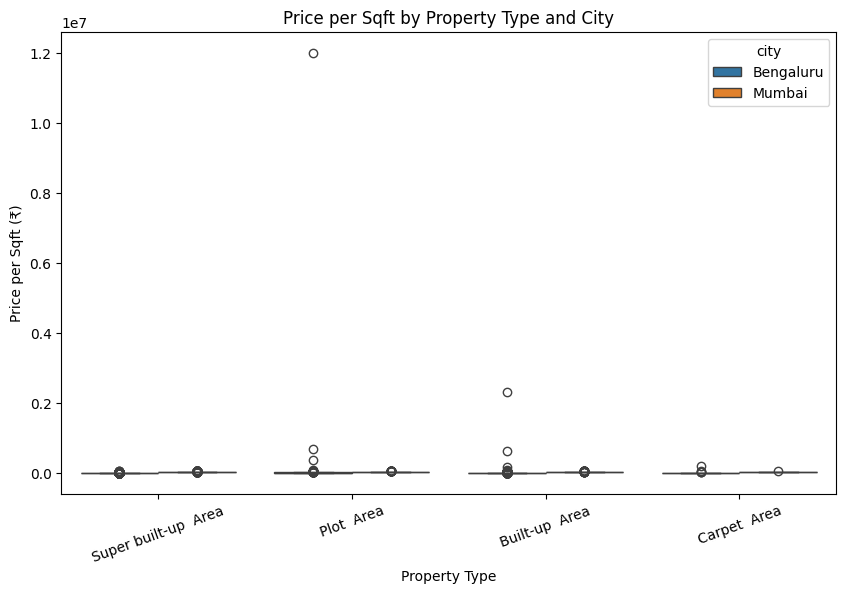

In [65]:
plt.figure(figsize=(10,6))
sns.boxplot(
    data=df,
    x="area_type",
    y="price_per_sqft",
    hue="city"
)
plt.title("Price per Sqft by Property Type and City")
plt.xlabel("Property Type")
plt.ylabel("Price per Sqft (₹)")
plt.xticks(rotation=20)
plt.show()

### Hypothesis 1 — Property price

H₀: There is no statistically significant difference in property prices between Bengaluru and Mumbai.

H₁: There is a statistically significant difference.

Because real-estate prices are usually skewed and the two groups have different variances, use Welch's t-test rather than the basic Student's t-test.

In [66]:
from scipy.stats import ttest_ind

bengaluru_price = df[df["city"] == "Bengaluru"]["price"]
mumbai_price = df[df["city"] == "Mumbai"]["price"]

t_stat, p_value = ttest_ind(
    bengaluru_price,
    mumbai_price,
    equal_var=False
)

print("Welch's t-test")
print("t-statistic:", t_stat)
print("p-value:", p_value)

alpha = 0.05

if p_value < alpha:
    print("Reject H0: The difference in mean property prices is statistically significant.")
else:
    print("Fail to reject H0: Insufficient evidence of a difference in mean property prices.")

Welch's t-test
t-statistic: -161.66855388141195
p-value: 0.0
Reject H0: The difference in mean property prices is statistically significant.


#### Hypothesis 2 — Price per sqft

This is actually more interesting for your project.

H₀: There is no statistically significant difference in price per sqft between Bengaluru and Mumbai.

H₁: There is a statistically significant difference.

In [67]:
bengaluru_pps = df[df["city"] == "Bengaluru"]["price_per_sqft"]
mumbai_pps = df[df["city"] == "Mumbai"]["price_per_sqft"]

t_stat_pps, p_value_pps = ttest_ind(
    bengaluru_pps,
    mumbai_pps,
    equal_var=False
)

print("Welch's t-test — Price per Sqft")
print("t-statistic:", t_stat_pps)
print("p-value:", p_value_pps)

if p_value_pps < 0.05:
    print("Reject H0: The difference in mean price per sqft is statistically significant.")
else:
    print("Fail to reject H0: Insufficient evidence of a difference.")

Welch's t-test — Price per Sqft
t-statistic: -21.6864586202237
p-value: 1.6191642913003586e-102
Reject H0: The difference in mean price per sqft is statistically significant.


In [68]:
print("Hypothesis Testing Summary")
print("-" * 40)

print(f"Property Price p-value   : {p_value:.6f}")
print(f"Price per Sqft p-value   : {p_value_pps:.6f}")

if p_value < 0.05:
    print("\nProperty prices show a statistically significant difference between cities.")

if p_value_pps < 0.05:
    print("Price per sqft also shows a statistically significant difference between cities.")

Hypothesis Testing Summary
----------------------------------------
Property Price p-value   : 0.000000
Price per Sqft p-value   : 0.000000

Property prices show a statistically significant difference between cities.
Price per sqft also shows a statistically significant difference between cities.


### Non-Parametric Hypothesis Testing

Real-estate prices may not follow a normal distribution. Therefore, the Mann–Whitney U test is also applied as a non-parametric comparison between Bengaluru and Mumbai.

In [70]:
from scipy.stats import mannwhitneyu

u_price, p_price_mw = mannwhitneyu(
    bengaluru_price,
    mumbai_price,
    alternative="two-sided"
)

u_pps, p_pps_mw = mannwhitneyu(
    bengaluru_pps,
    mumbai_pps,
    alternative="two-sided"
)

print("Mann–Whitney U Test")
print("-" * 40)

print(f"Property Price p-value : {p_price_mw:.6f}")
print(f"Price/sqft p-value     : {p_pps_mw:.6f}")

Mann–Whitney U Test
----------------------------------------
Property Price p-value : 0.000000
Price/sqft p-value     : 0.000000


# 11. Machine Learning — Multi-City Property Price Prediction

Machine learning models are developed to predict residential property prices using structural, property-type and geographical attributes.

Three feature configurations are evaluated:

1. Property-only features
2. Property + city
3. Property + city + location

This allows us to measure the contribution of geographical information to property price prediction.

The models are evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² score.

In [76]:
features_base = [
    "bhk", "total_sqft", "bath", "balcony", "area_type"
]

features_city = features_base + ["city"]

features_location = features_city + ["location"]

target = "price"

In [78]:
from sklearn.model_selection import train_test_split

X = df[features_location]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

Training samples: 19522
Testing samples : 4881


## Model Development

Linear Regression and Ridge Regression provide linear baselines, while Random Forest and Gradient Boosting capture non-linear relationships between property characteristics, location and price.

In [79]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Random Forest": RandomForestRegressor(
        n_estimators=150,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=150,
        random_state=42
    )
}

In [80]:
results = []
trained_models = {}

numeric_features = ["bhk", "total_sqft", "bath", "balcony"]
categorical_features = ["area_type", "city", "location"]

for name, model in models.items():

    preprocessor = ColumnTransformer([
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         categorical_features)
    ])

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": mean_squared_error(y_test, y_pred) ** 0.5,
        "R2": r2_score(y_test, y_pred)
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)

display(results_df)

,Model,MAE,RMSE,R2
2,Random Forest,30.238514,72.451229,0.844706
3,Gradient Boosting,32.465979,72.871910,0.842898
1,Ridge Regression,47.056829,94.501001,0.735799
0,Linear Regression,47.463476,97.299192,0.719921


## Impact of Geographical Features

The effect of geographical information is evaluated by comparing models trained with property attributes alone, property attributes with city, and property attributes with both city and location.

In [81]:
feature_sets = {
    "Property Only": features_base,
    "Property + City": features_city,
    "Property + City + Location": features_location
}

feature_results = []

for feature_name, feature_list in feature_sets.items():

    X_exp = df[feature_list]
    y_exp = df["price"]

    Xtr, Xte, ytr, yte = train_test_split(
        X_exp, y_exp,
        test_size=0.20,
        random_state=42
    )

    numeric = [c for c in feature_list if c in numeric_features]
    categorical = [c for c in feature_list if c not in numeric_features]

    prep = ColumnTransformer([
        ("num", "passthrough", numeric),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)
    ])

    pipe = Pipeline([
        ("preprocessor", prep),
        ("model", RandomForestRegressor(
            n_estimators=150,
            random_state=42,
            n_jobs=-1
        ))
    ])

    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)

    feature_results.append({
        "Feature Set": feature_name,
        "MAE": mean_absolute_error(yte, pred),
        "RMSE": mean_squared_error(yte, pred) ** 0.5,
        "R2": r2_score(yte, pred)
    })

feature_results_df = pd.DataFrame(feature_results)

display(feature_results_df)

,Feature Set,MAE,RMSE,R2
0,Property Only,170.837849,192.967583,-0.101618
1,Property + City,34.853890,81.757970,0.802247
2,Property + City + Location,30.238514,72.451229,0.844706


In [82]:
best_model_name = results_df.iloc[0]["Model"]

final_model = trained_models[best_model_name]

print("Selected model:", best_model_name)

Selected model: Random Forest


In [83]:
final_predictions = final_model.predict(X_test)

print("Final Model:", best_model_name)
print("MAE :", mean_absolute_error(y_test, final_predictions))
print("RMSE:", mean_squared_error(y_test, final_predictions) ** 0.5)
print("R²  :", r2_score(y_test, final_predictions))

Final Model: Random Forest
MAE : 30.238514361507974
RMSE: 72.45122912000964
R²  : 0.8447063496308167


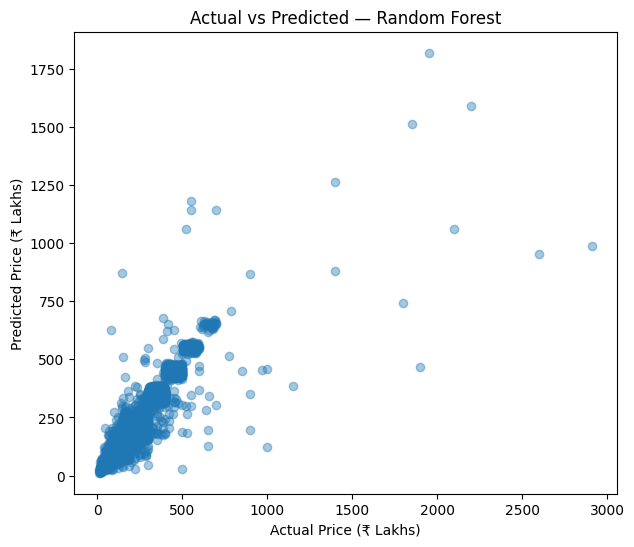

In [84]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, final_predictions, alpha=0.4)

plt.xlabel("Actual Price (₹ Lakhs)")
plt.ylabel("Predicted Price (₹ Lakhs)")
plt.title(f"Actual vs Predicted — {best_model_name}")

plt.show()

In [85]:
def recommend_properties(
    city,
    location,
    bhk,
    total_sqft,
    bath,
    balcony,
    area_type,
    budget
):

    # Predict expected price
    input_data = pd.DataFrame([{
        "city": city,
        "location": location,
        "bhk": bhk,
        "total_sqft": total_sqft,
        "bath": bath,
        "balcony": balcony,
        "area_type": area_type
    }])

    predicted_price = final_model.predict(input_data)[0]

    # Filter properties
    recommendations = df[
        (df["city"].str.lower() == city.lower()) &
        (df["bhk"] == bhk) &
        (df["price"] <= budget)
    ].copy()

    if location:
        recommendations = recommendations[
            recommendations["location"].str.lower().str.contains(
                location.lower(), na=False
            )
        ]

    if recommendations.empty:
        print("No matching properties found.")
        print(f"Predicted market price: ₹{predicted_price:.2f} lakhs")
        return

    recommendations["price_difference"] = (
        recommendations["price"] - predicted_price
    ).abs()

    recommendations = recommendations.sort_values(
        "price_difference"
    )

    print(f"Predicted Price: ₹{predicted_price:.2f} lakhs")
    
    display(
        recommendations[
            [
                "city",
                "location",
                "bhk",
                "total_sqft",
                "bath",
                "balcony",
                "area_type",
                "price"
            ]
        ].head(10)
    )

In [86]:
recommend_properties(
    city="Bengaluru",
    location="Whitefield",
    bhk=2,
    total_sqft=1200,
    bath=2,
    balcony=1,
    area_type="Super built-up  Area",
    budget=100
)

Predicted Price: ₹46.38 lakhs


,city,location,bhk,total_sqft,bath,balcony,area_type,price
9672,Bengaluru,Whitefield,2,1100.0,2.0,1,Super built-up Area,46.50
3236,Bengaluru,Whitefield,2,1200.0,2.0,1,Plot Area,46.13
11313,Bengaluru,Whitefield,2,1200.0,2.0,1,Plot Area,46.13
6279,Bengaluru,Whitefield,2,1200.0,2.0,2,Plot Area,46.13
6286,Bengaluru,Whitefield,2,1200.0,2.0,1,Plot Area,46.13
1072,Bengaluru,Whitefield,2,1200.0,2.0,1,Plot Area,45.84
3869,Bengaluru,Whitefield,2,1200.0,2.0,1,Super built-up Area,45.84
11331,Bengaluru,Whitefield,2,1200.0,2.0,1,Plot Area,45.84
5568,Bengaluru,Whitefield,2,1235.0,2.0,2,Super built-up Area,47.00
202,Bengaluru,Whitefield,2,1225.0,2.0,2,Built-up Area,47.60


In [87]:
df["area_type"].unique()

array(['Super built-up  Area', 'Plot  Area', 'Built-up  Area',
       'Carpet  Area'], dtype=object)

In [88]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(final_model, "models/final_property_price_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


# 12. Final Model Evaluation

Since property price prediction is a regression problem, classification metrics such as accuracy, precision and recall are not applicable.

The final model is evaluated using MAE, MSE, RMSE, R² and MAPE.

In [89]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

y_pred = final_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred) * 100

final_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²", "MAPE"],
    "Value": [mae, mse, rmse, r2, mape]
})

display(final_metrics)

,Metric,Value
0,MAE,30.238514
1,MSE,5249.180601
2,RMSE,72.451229
3,R²,0.844706
4,MAPE,16.443642


In [90]:
print(f"Final Model: {best_model_name}")
print(f"MAE  : ₹{mae:.2f} Lakhs")
print(f"RMSE : ₹{rmse:.2f} Lakhs")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

Final Model: Random Forest
MAE  : ₹30.24 Lakhs
RMSE : ₹72.45 Lakhs
R²   : 0.8447
MAPE : 16.44%


# 13. Interactive Buyer Property Finder

The Buyer Property Finder allows users to search for suitable properties using basic requirements such as city, BHK and budget.

The system accepts flexible user input, handles common city aliases, validates numerical inputs, and allows optional filtering by location, area, bathrooms and property type.

Matching properties can be sorted according to price, area or price per square foot. The final results also include the ML-estimated property price.

In [97]:
def get_text(prompt, required=True):
    while True:
        value = input(prompt).strip()

        if required and not value:
            print("❌ This field cannot be empty. Please try again.")
            continue

        return value


def get_positive_number(prompt, integer=False, required=True):
    while True:
        value = input(prompt).strip()

        if not value and not required:
            return None

        try:
            number = float(value)

            if number <= 0:
                print("❌ Please enter a value greater than 0.")
                continue

            if integer:
                if not number.is_integer():
                    print("❌ Please enter a whole number.")
                    continue
                return int(number)

            return number

        except ValueError:
            print("❌ Please enter a valid number.")


def get_optional_number(prompt, integer=False):
    while True:
        value = input(prompt).strip()

        if value == "":
            return None

        try:
            number = float(value)

            if number < 0:
                print("❌ Please enter 0 or a positive number.")
                continue

            if integer:
                if not number.is_integer():
                    print("❌ Please enter a whole number.")
                    continue
                return int(number)

            return number

        except ValueError:
            print("❌ Please enter a valid number or press Enter to skip.")

In [98]:
city_aliases = {
    "bengaluru": "Bengaluru",
    "bangalore": "Bengaluru",
    "blr": "Bengaluru",

    "mumbai": "Mumbai",
    "bombay": "Mumbai",
    "bom": "Mumbai"
}

In [102]:
print("\n" + "=" * 60)
print("🏠 MULTI-CITY BUYER PROPERTY FINDER")
print("=" * 60)

print("\nAvailable cities:")
print("• Bengaluru / Bangalore")
print("• Mumbai / Bombay")

# ---------------- CITY ----------------

while True:
    city_input = get_text("\nEnter city: ").lower()

    if city_input in city_aliases:
        buyer_city = city_aliases[city_input]
        break

    print("❌ City not available.")
    print("Please choose Bengaluru/Bangalore or Mumbai/Bombay.")


# ---------------- BHK ----------------

print("\nAvailable BHK values:")
print(sorted(df["bhk"].dropna().unique().astype(int)))

buyer_bhk = get_positive_number(
    "\nEnter required BHK: ",
    integer=True
)


# ---------------- BUDGET ----------------

buyer_budget = get_positive_number(
    "Enter maximum budget (₹ Lakhs): "
)


# ---------------- OPTIONAL LOCATION ----------------

available_locations = sorted(
    df[df["city"] == buyer_city]["location"]
    .dropna()
    .unique()
)

print("\nLocation is optional.")
print("Examples:", ", ".join(available_locations[:10]))

buyer_location = input(
    "Preferred location (press Enter for any): "
).strip()


# ---------------- OPTIONAL AREA ----------------

buyer_min_area = get_optional_number(
    "Minimum area in sqft (press Enter for any): "
)


# ---------------- OPTIONAL BATHROOM ----------------

buyer_bath = get_optional_number(
    "Minimum bathrooms (press Enter for any): ",
    integer=True
)


# ---------------- OPTIONAL AREA TYPE ----------------

available_area_types = sorted(
    df["area_type"].dropna().unique()
)

print("\nAvailable property types:")
for i, area_type in enumerate(available_area_types, 1):
    print(f"{i}. {area_type}")

buyer_area_type = input(
    "\nProperty type (press Enter for any): "
).strip()

if buyer_area_type:
    matching_types = [
        x for x in available_area_types
        if x.lower() == buyer_area_type.lower()
    ]

    if matching_types:
        buyer_area_type = matching_types[0]
    else:
        print("⚠️ Property type not recognized.")
        print("Continuing without property-type filtering.")
        buyer_area_type = None
else:
    buyer_area_type = None


🏠 MULTI-CITY BUYER PROPERTY FINDER

Available cities:
• Bengaluru / Bangalore
• Mumbai / Bombay



Enter city:  Bengaluru



Available BHK values:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 16, 18, 19, 27, 43]



Enter required BHK:  2
Enter maximum budget (₹ Lakhs):  200



Location is optional.
Examples:  Anekal,  Banaswadi,  Basavangudi,  Bhoganhalli,  Devarabeesana Halli,  Devarachikkanahalli,  Electronic City,  Mysore Highway,  Rachenahalli,  Sector 1 HSR Layout


Preferred location (press Enter for any):  
Minimum area in sqft (press Enter for any):  
Minimum bathrooms (press Enter for any):  



Available property types:
1. Built-up  Area
2. Carpet  Area
3. Plot  Area
4. Super built-up  Area



Property type (press Enter for any):  


In [103]:
recommendations = df.copy()

# City
recommendations = recommendations[
    recommendations["city"] == buyer_city
]

# BHK
recommendations = recommendations[
    recommendations["bhk"] == buyer_bhk
]

# Budget
recommendations = recommendations[
    recommendations["price"] <= buyer_budget
]

# Optional location
if buyer_location:
    recommendations = recommendations[
        recommendations["location"]
        .str.lower()
        .str.contains(
            buyer_location.lower(),
            na=False
        )
    ]

# Optional area
if buyer_min_area is not None:
    recommendations = recommendations[
        recommendations["total_sqft"] >= buyer_min_area
    ]

# Optional bathroom
if buyer_bath is not None:
    recommendations = recommendations[
        recommendations["bath"] >= buyer_bath
    ]

# Optional property type
if buyer_area_type:
    recommendations = recommendations[
        recommendations["area_type"] == buyer_area_type
    ]

In [104]:
if recommendations.empty:

    print("\n❌ No properties matched your requirements.")
    print("Try increasing the budget or removing optional filters.")

else:

    prediction_features = [
        "bhk",
        "total_sqft",
        "bath",
        "balcony",
        "area_type",
        "city",
        "location"
    ]

    recommendations = recommendations.copy()

    recommendations["predicted_price"] = final_model.predict(
        recommendations[prediction_features]
    )

    recommendations["price_difference"] = (
        recommendations["price"]
        - recommendations["predicted_price"]
    )

    recommendations["price_difference"] = (
        recommendations["price_difference"].round(2)
    )

    print(
        f"\n✅ {len(recommendations)} matching properties found."
    )


✅ 5489 matching properties found.


In [105]:
if not recommendations.empty:

    print("\nSort results by:")
    print("1. Lowest Price")
    print("2. Largest Area")
    print("3. Lowest Price per Sqft")
    print("4. Closest to ML Estimated Price")

    while True:

        sort_choice = input(
            "\nEnter choice (1-4): "
        ).strip()

        if sort_choice == "1":
            recommendations = recommendations.sort_values(
                "price",
                ascending=True
            )
            break

        elif sort_choice == "2":
            recommendations = recommendations.sort_values(
                "total_sqft",
                ascending=False
            )
            break

        elif sort_choice == "3":
            recommendations = recommendations.sort_values(
                "price_per_sqft",
                ascending=True
            )
            break

        elif sort_choice == "4":
            recommendations = recommendations.sort_values(
                "price_difference",
                key=lambda x: x.abs(),
                ascending=True
            )
            break

        else:
            print("❌ Please enter a number between 1 and 4.")


Sort results by:
1. Lowest Price
2. Largest Area
3. Lowest Price per Sqft
4. Closest to ML Estimated Price



Enter choice (1-4):  1


In [106]:
if not recommendations.empty:

    display(
        recommendations[
            [
                "city",
                "location",
                "bhk",
                "total_sqft",
                "bath",
                "balcony",
                "area_type",
                "price",
                "predicted_price",
                "price_difference",
                "price_per_sqft"
            ]
        ].head(10)
    )

,city,location,bhk,total_sqft,bath,balcony,area_type,price,predicted_price,price_difference,price_per_sqft
8653,Bengaluru,Doddaballapur,2,640.0,1.0,0,Plot Area,10.5,22.186667,-11.69,1640.625000
11173,Bengaluru,Kadabagere,2,675.0,2.0,2,Super built-up Area,13.5,22.144270,-8.64,2000.000000
9252,Bengaluru,Kadabagere,2,565.0,2.0,1,Built-up Area,15.0,19.200000,-4.20,2654.867257
2040,Bengaluru,Electronic City,2,550.0,1.0,1,Super built-up Area,15.0,15.492349,-0.49,2727.272727
3888,Bengaluru,Electronic City,2,550.0,1.0,1,Super built-up Area,15.0,15.492349,-0.49,2727.272727
4786,Bengaluru,Electronic City,2,660.0,1.0,1,Super built-up Area,15.0,18.883926,-3.88,2272.727273
5652,Bengaluru,JP Nagar,2,1100.0,1.0,1,Built-up Area,15.0,27.996067,-13.00,1363.636364
7028,Bengaluru,Kadabagere,2,675.0,1.0,1,Super built-up Area,15.0,19.753733,-4.75,2222.222222
7825,Bengaluru,Electronic City,2,550.0,1.0,1,Built-up Area,15.0,15.849111,-0.85,2727.272727
833,Bengaluru,Belathur,2,460.0,1.0,0,Super built-up Area,15.0,25.009722,-10.01,3260.869565


In [107]:
if not recommendations.empty:

    print("\n🏆 TOP PROPERTY OPTIONS")
    print("-" * 60)

    for i, (_, row) in enumerate(
        recommendations.head(5).iterrows(),
        1
    ):

        print(
            f"{i}. {row['location']} | "
            f"{int(row['bhk'])} BHK | "
            f"{row['total_sqft']:.0f} sqft | "
            f"₹{row['price']:.2f} Lakhs | "
            f"ML Estimate: ₹{row['predicted_price']:.2f} Lakhs"
        )


🏆 TOP PROPERTY OPTIONS
------------------------------------------------------------
1. Doddaballapur | 2 BHK | 640 sqft | ₹10.50 Lakhs | ML Estimate: ₹22.19 Lakhs
2. Kadabagere | 2 BHK | 675 sqft | ₹13.50 Lakhs | ML Estimate: ₹22.14 Lakhs
3. Kadabagere | 2 BHK | 565 sqft | ₹15.00 Lakhs | ML Estimate: ₹19.20 Lakhs
4. Electronic City | 2 BHK | 550 sqft | ₹15.00 Lakhs | ML Estimate: ₹15.49 Lakhs
5. Electronic City | 2 BHK | 550 sqft | ₹15.00 Lakhs | ML Estimate: ₹15.49 Lakhs


# 14. Conclusion

This project developed a multi-city real-estate analytics and machine learning framework for residential property price prediction and buyer-oriented property discovery. Property datasets from Bengaluru and Mumbai were integrated, cleaned, transformed and analyzed through univariate, bivariate and trivariate EDA, statistical hypothesis testing and feature engineering.

Multiple regression models were evaluated using MAE, MSE, RMSE, R² and MAPE. The effect of geographical information was also examined by comparing models using property attributes alone, property attributes with city, and property attributes with city and location. The resulting system extends beyond price prediction through an interactive Buyer Property Finder, allowing users to specify requirements such as city, BHK, budget and optional preferences and receive filtered and ranked property options along with ML-based price estimates.

The project demonstrates how publicly available real-estate data can be transformed into an analytical decision-support system combining data engineering, exploratory analysis, statistical testing, machine learning and user-oriented property search.

## Data Availability and Limitations

The datasets used in this project were obtained from publicly accessible datasets available through Kaggle. They represent historical/listing data and therefore the prices shown in the analysis and predictions may differ from current market prices.

Live real-estate scraping was not implemented because automated extraction from property websites may be restricted by website terms of service, access policies and other legal or technical constraints. Publicly accessible APIs suitable for this project were either unavailable, restricted, or required paid access. Therefore, using publicly available datasets was selected as the compliant and practical approach for this implementation.

Consequently, this project should be considered an analytical and predictive framework rather than a source of live property prices. Future versions can incorporate legally permitted real-time or regularly updated data sources, subject to their terms of use and availability.

# Workflow

1. Project Introduction

2. Load Bengaluru Dataset
3. Load Mumbai Dataset

4. Data Integration
5. Data Cleaning
6. Missing Value Handling
7. Feature Engineering

8. Outlier Analysis
   ├── Visualization
   ├── IQR detection
   ├── Investigation
   └── Decision to retain/flag

9. Correlation Analysis

10. Univariate Analysis

11. Bivariate Analysis

12. Trivariate Analysis

13. Price-per-sqft Market Analysis

14. Hypothesis Testing
   ├── Welch's t-test
   └── Mann–Whitney U test

15. Save Cleaned Dataset

16. Machine Learning
   ├── Feature configurations
   ├── Train/test split
   ├── Preprocessing
   ├── Linear Regression
   ├── Ridge
   ├── Random Forest
   ├── Gradient Boosting
   ├── Model comparison
   └── Feature-set comparison

17. Cross-validation

18. Hyperparameter Tuning

19. Final Model Evaluation

20. Actual vs Predicted

21. Residual/Error Analysis

22. Save Final Model

23. Flask Deployment